# Crop Yield Prediction

Voici mon travail de prédiction du rendement agricole (crop yield) réalisé dans le cadre de la matière Fouille de données. Le travail s’inspire du notebook DM_Insurance_Guide, qui a servi de base pour suivre les différentes étapes : exploration des données, prétraitement, modélisation et évaluation. Les réponses aux questions demandées sont présentées à la fin du notebook.

## 0. Environment and package installation

In [1]:
%pip install -q imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, silhouette_score, roc_auc_score
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


RANDOM_STATE = 42


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 1. Load the data
The notebook first tries to read the local CSV file delivered with the notebook.

In [2]:
from pathlib import Path

possible_paths = [
    Path("09_Crop_Yield.csv")
]

data_path = None
for p in possible_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("09_Crop_Yield.csv not found.")

df = pd.read_csv(data_path)
print("Data loaded from:", data_path)
print("Shape:", df.shape)
display(df.head())

Data loaded from: 09_Crop_Yield.csv
Shape: (1220, 13)


,age,experience_or_tenure,feature_score_1,feature_score_2,exposure_index,event_count_1,event_count_2,segment,intensity_level,area_type,special_flag,season,yield_value
0,65,17,31.79,49.31,34.49,4.0,0,B,low,rural,no,autumn,8520.03
1,44,16,80.06,57.23,62.54,1.0,3,A,medium,urban,no,winter,13124.39
2,36,10,69.51,67.73,12.23,1.0,2,A,medium,suburban,no,winter,8684.28
3,47,26,64.94,60.71,NaN,2.0,2,B,medium,urban,no,spring,15772.50
4,24,12,37.61,44.68,39.61,8.0,2,A,medium,suburban,yes,spring,12614.65


## 2. Initial inspection
This first diagnostic stage is mandatory before any preprocessing.

In [3]:
print("Data types:")
display(df.dtypes)

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicated rows:", df.duplicated().sum())

target = "yield_value"
all_features = [c for c in df.columns if c != target]

numerical_features = [c for c in df.select_dtypes(include=np.number).columns if c != target]
categorical_features = [c for c in df.select_dtypes(exclude=np.number).columns]

print("\nTarget variable:", target)
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Data types:


age                       int64
experience_or_tenure      int64
feature_score_1         float64
feature_score_2         float64
exposure_index          float64
event_count_1           float64
event_count_2             int64
segment                  object
intensity_level          object
area_type                object
special_flag             object
season                   object
yield_value             float64
dtype: object


Missing values per column:


exposure_index          97
feature_score_1         73
feature_score_2         61
segment                 36
event_count_1           36
intensity_level         36
area_type               24
special_flag            24
age                      0
experience_or_tenure     0
event_count_2            0
season                   0
yield_value              0
dtype: int64


Duplicated rows: 0

Target variable: yield_value
Numerical features: ['age', 'experience_or_tenure', 'feature_score_1', 'feature_score_2', 'exposure_index', 'event_count_1', 'event_count_2']
Categorical features: ['segment', 'intensity_level', 'area_type', 'special_flag', 'season']


## 3. Descriptive statistics

### 3.1 Numerical statistics
We compute the classical statistics, but we also add **variance**, **skewness**, and **kurtosis** because they are crucial for preprocessing decisions.

In [4]:
num_desc = df[numerical_features + [target]].describe().T
num_desc["median"] = df[numerical_features + [target]].median(numeric_only=True)
num_desc["variance"] = df[numerical_features + [target]].var(numeric_only=True)
num_desc["skewness"] = df[numerical_features + [target]].skew(numeric_only=True)
num_desc["kurtosis"] = df[numerical_features + [target]].kurtosis(numeric_only=True)
display(num_desc)

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,kurtosis
age,1220.0,44.528689,14.888043,18.00,31.000,45.00,58.000,69.00,45.00,2.216538e+02,-0.073496,-1.209735
experience_or_tenure,1220.0,14.783607,8.950638,0.00,7.000,15.00,23.000,30.00,15.00,8.011392e+01,0.014283,-1.229702
feature_score_1,1147.0,59.739058,17.714760,7.62,47.570,60.05,71.995,100.00,60.05,3.138127e+02,-0.030568,-0.382595
feature_score_2,1159.0,55.344832,21.605706,0.00,40.165,56.18,71.305,100.00,56.18,4.668065e+02,-0.111026,-0.462519
exposure_index,1123.0,25.857783,16.402219,3.54,14.820,21.82,31.935,106.66,21.82,2.690328e+02,1.821142,4.408887
event_count_1,1184.0,3.576014,1.930132,0.00,2.000,3.00,5.000,12.00,3.00,3.725409e+00,0.697827,0.745596
event_count_2,1220.0,1.770492,1.366341,0.00,1.000,2.00,3.000,9.00,2.00,1.866889e+00,0.910226,1.230242
yield_value,1220.0,10528.583934,2257.301685,4251.46,8979.290,10439.25,11941.845,18735.76,10439.25,5.095411e+06,0.327079,0.225679


### 3.2 Categorical statistics
Frequency distributions help identify dominant classes, rare modalities, and possible imbalance.

In [5]:
for col in categorical_features:
    print(f"\n===== {col} =====")
    display(pd.DataFrame({
        "count": df[col].value_counts(dropna=False),
        "proportion": df[col].value_counts(dropna=False, normalize=True)
    }))


===== segment =====


,count,proportion
segment,,
B,376,0.308197
A,327,0.268033
C,300,0.245902
D,181,0.148361
NaN,36,0.029508



===== intensity_level =====


,count,proportion
intensity_level,,
medium,562,0.460656
low,394,0.322951
high,228,0.186885
NaN,36,0.029508



===== area_type =====


,count,proportion
area_type,,
urban,483,0.395902
suburban,415,0.340164
rural,298,0.244262
NaN,24,0.019672



===== special_flag =====


,count,proportion
special_flag,,
no,854,0.700000
yes,342,0.280328
NaN,24,0.019672



===== season =====


,count,proportion
season,,
winter,329,0.269672
autumn,303,0.248361
summer,295,0.241803
spring,293,0.240164


## 4. Missing values analysis and imputation strategy

We do **not** impute blindly.

Decision rules used here:

- numerical variable with low skewness: **mean** imputation
- numerical variable with high skewness: **median** imputation
- categorical or discrete variable: **most frequent** imputation

In [6]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str)
}).sort_values("missing_pct", ascending=False)

display(missing_table)

skewness_abs = df[numerical_features].skew(numeric_only=True).abs().sort_values(ascending=False)
display(pd.DataFrame({"abs_skewness": skewness_abs}))

mean_impute_cols = [c for c in numerical_features if abs(df[c].skew(skipna=True)) < 0.75]
median_impute_cols = [c for c in numerical_features if c not in mean_impute_cols]

print("Mean imputation columns:", mean_impute_cols)
print("Median imputation columns:", median_impute_cols)
print("Mode imputation columns:", categorical_features)

,missing_count,missing_pct,dtype
exposure_index,97,7.950820,float64
feature_score_1,73,5.983607,float64
feature_score_2,61,5.000000,float64
segment,36,2.950820,object
event_count_1,36,2.950820,float64
intensity_level,36,2.950820,object
area_type,24,1.967213,object
special_flag,24,1.967213,object
age,0,0.000000,int64
experience_or_tenure,0,0.000000,int64


,abs_skewness
exposure_index,1.821142
event_count_2,0.910226
event_count_1,0.697827
feature_score_2,0.111026
age,0.073496
feature_score_1,0.030568
experience_or_tenure,0.014283


Mean imputation columns: ['age', 'experience_or_tenure', 'feature_score_1', 'feature_score_2', 'event_count_1']
Median imputation columns: ['exposure_index', 'event_count_2']
Mode imputation columns: ['segment', 'intensity_level', 'area_type', 'special_flag', 'season']


## 5. Outlier analysis

We use the IQR rule to detect potentially extreme values.  
This does not automatically mean they must be deleted; it helps decide whether robust preprocessing is needed.

In [7]:
def outlier_summary_iqr(data, cols):
    rows = []
    for col in cols + [target]:
        x = data[col].dropna()
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_out = ((x < low) | (x > high)).sum()
        rows.append({
            "feature": col,
            "n_outliers": int(n_out),
            "pct_outliers": 100 * n_out / len(x),
            "lower_bound": low,
            "upper_bound": high
        })
    return pd.DataFrame(rows).sort_values("pct_outliers", ascending=False)

outlier_table = outlier_summary_iqr(df, numerical_features)
display(outlier_table)

,feature,n_outliers,pct_outliers,lower_bound,upper_bound
4,exposure_index,62,5.520926,-10.8525,57.6075
7,yield_value,17,1.393443,4535.4575,16385.6775
5,event_count_1,9,0.760135,-2.5000,9.5000
6,event_count_2,5,0.409836,-2.0000,6.0000
2,feature_score_1,1,0.087184,10.9325,108.6325
3,feature_score_2,0,0.000000,-6.5450,118.0150
0,age,0,0.000000,-9.5000,98.5000
1,experience_or_tenure,0,0.000000,-17.0000,47.0000


## 6. Distribution analysis

Histograms and boxplots are used to understand symmetry, tails, concentration, and outliers.

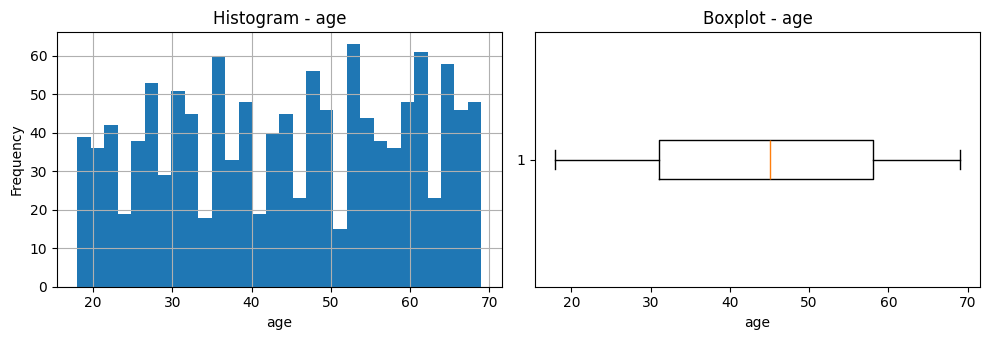

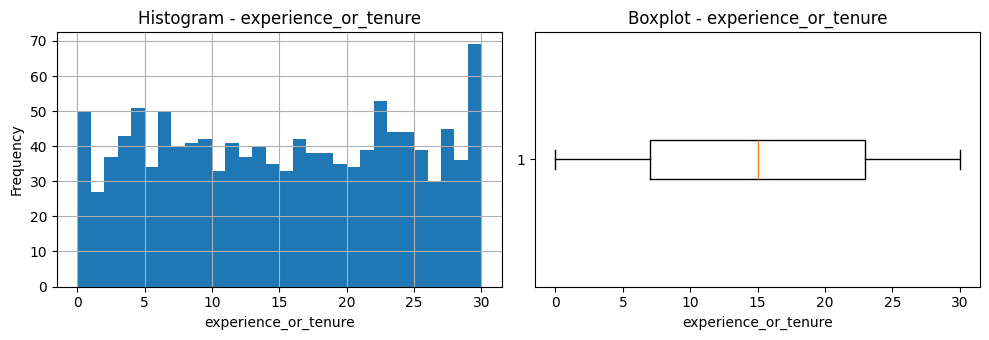

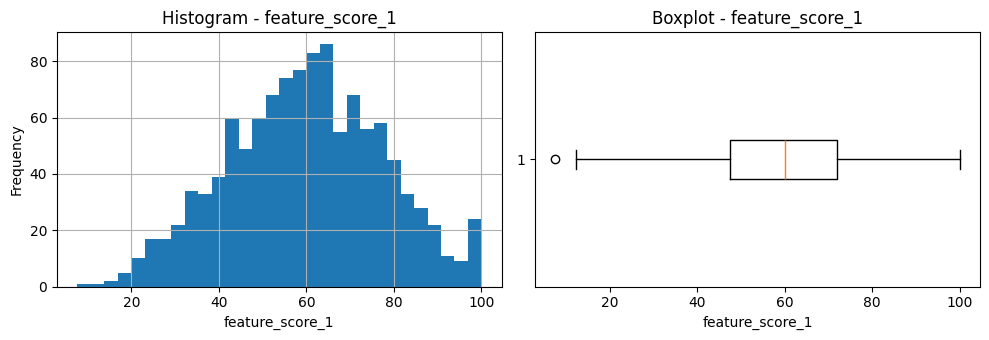

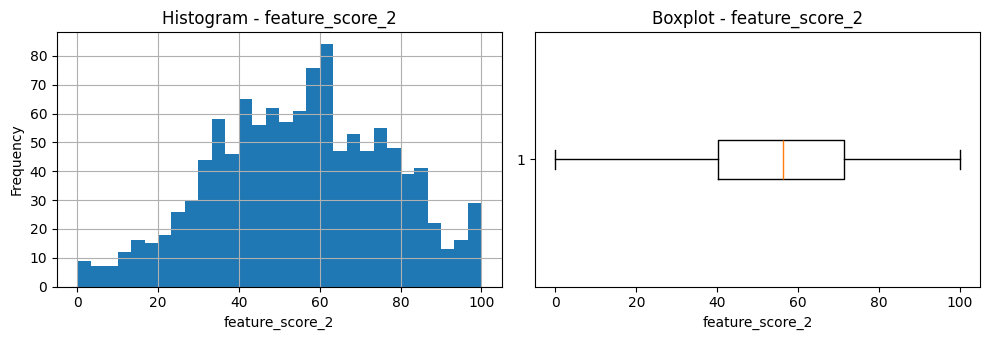

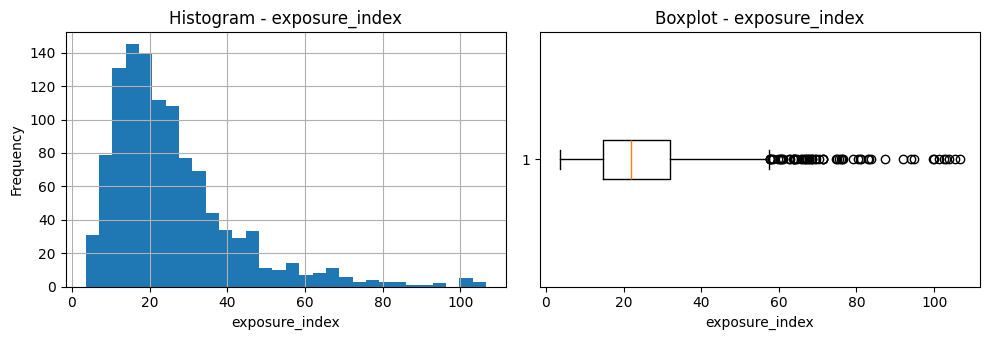

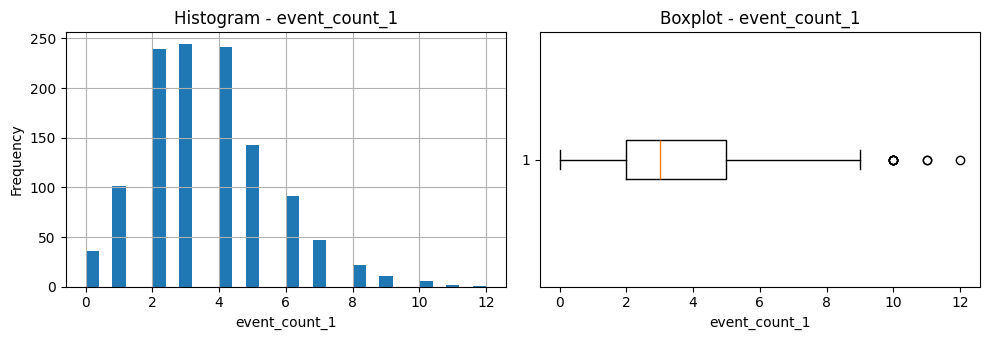

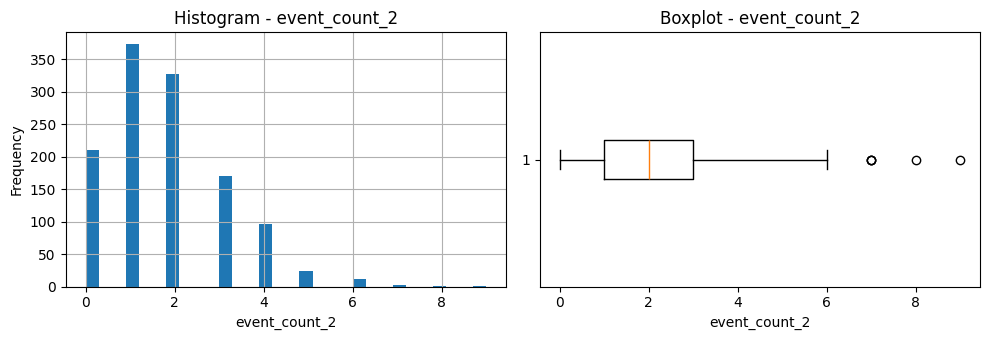

In [8]:
for col in numerical_features[:]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    df[col].hist(bins=30, ax=axes[0])
    axes[0].set_title(f"Histogram - {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    axes[1].boxplot(df[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot - {col}")
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

## 7. Several correlation analyses

A complete study should not rely on a single correlation coefficient.

We use:

- **Pearson**: linear correlation between numerical variables
- **Spearman**: monotonic relationship, more robust to non-normality and outliers
- **Kendall**: rank-based association
- **Cramér's V**: association between categorical variables
- **ANOVA / eta-style reasoning**: categorical predictors vs continuous target
- **Mutual information**: non-linear dependence

In [9]:
pearson_corr = df[numerical_features + [target]].corr(method="pearson")
spearman_corr = df[numerical_features + [target]].corr(method="spearman")
kendall_corr = df[numerical_features + [target]].corr(method="kendall")

print("Pearson correlation with target:")
display(pearson_corr[[target]].sort_values(target, ascending=False))

print("Spearman correlation with target:")
display(spearman_corr[[target]].sort_values(target, ascending=False))

print("Kendall correlation with target:")
display(kendall_corr[[target]].sort_values(target, ascending=False))

Pearson correlation with target:


,yield_value
yield_value,1.000000
exposure_index,0.535668
feature_score_2,0.410517
feature_score_1,0.240181
event_count_2,0.182955
event_count_1,0.158797
experience_or_tenure,0.156395
age,0.113927


Spearman correlation with target:


,yield_value
yield_value,1.000000
exposure_index,0.450312
feature_score_2,0.398446
feature_score_1,0.242804
event_count_2,0.182065
event_count_1,0.160574
experience_or_tenure,0.157510
age,0.109807


Kendall correlation with target:


,yield_value
yield_value,1.000000
exposure_index,0.311432
feature_score_2,0.274231
feature_score_1,0.164133
event_count_2,0.134816
event_count_1,0.113599
experience_or_tenure,0.106907
age,0.073888


In [10]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))

cramers_results = []
for i, col1 in enumerate(categorical_features):
    for col2 in categorical_features[i+1:]:
        temp = df[[col1, col2]].dropna()
        v = cramers_v(temp[col1], temp[col2])
        cramers_results.append({"var1": col1, "var2": col2, "cramers_v": v})

cramers_df = pd.DataFrame(cramers_results).sort_values("cramers_v", ascending=False)
display(cramers_df.head(10))

,var1,var2,cramers_v
6,intensity_level,season,0.051143
9,special_flag,season,0.050457
3,segment,season,0.043683
2,segment,special_flag,0.038574
0,segment,intensity_level,0.038005
5,intensity_level,special_flag,0.037880
1,segment,area_type,0.036794
8,area_type,season,0.033291
7,area_type,special_flag,0.032247
4,intensity_level,area_type,0.026448


In [11]:
anova_results = []
for col in categorical_features:
    temp = df[[col, target]].dropna()
    groups = [g[target].values for _, g in temp.groupby(col)]
    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        anova_results.append({"feature": col, "F_stat": f_stat, "p_value": p_value})

anova_df = pd.DataFrame(anova_results).sort_values("F_stat", ascending=False)
display(anova_df)

,feature,F_stat,p_value
3,special_flag,86.340549,6.954687e-20
1,intensity_level,70.632698,1.059040e-29
2,area_type,11.507914,1.121438e-05
4,season,11.028103,3.806938e-07
0,segment,4.402462,4.344278e-03


In [12]:
mi_input = df[numerical_features].copy()
for col in mi_input.columns:
    mi_input[col] = mi_input[col].fillna(mi_input[col].median())

mi_reg = mutual_info_regression(mi_input, df[target], random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": numerical_features, "mutual_information": mi_reg}).sort_values("mutual_information", ascending=False)
display(mi_df)

,feature,mutual_information
4,exposure_index,0.121708
3,feature_score_2,0.073788
5,event_count_1,0.065304
6,event_count_2,0.056537
2,feature_score_1,0.041772
0,age,0.009877
1,experience_or_tenure,0.008962


## 8. Statistical tests before modeling

These tests help guide the next choices.

- Normality test on the target
- Levene test for variance comparison across groups
- ANOVA / Kruskal-style reasoning if needed

In [13]:
sample_target = df[target].dropna()
sample_for_shapiro = sample_target.sample(min(5000, len(sample_target)), random_state=RANDOM_STATE)

shapiro_stat, shapiro_p = stats.shapiro(sample_for_shapiro)
print("Shapiro-Wilk test on target")
print("Statistic:", shapiro_stat)
print("p-value:", shapiro_p)

temp = df[["special_flag", target]].dropna()
group_yes = temp.loc[temp["special_flag"] == "yes", target]
group_no = temp.loc[temp["special_flag"] == "no", target]

levene_stat, levene_p = stats.levene(group_yes, group_no)
print("\nLevene test across special_flag groups")
print("Statistic:", levene_stat)
print("p-value:", levene_p)

mann_stat, mann_p = stats.mannwhitneyu(group_yes, group_no, alternative="two-sided")
print("\nMann-Whitney test between special_flag groups")
print("Statistic:", mann_stat)
print("p-value:", mann_p)

Shapiro-Wilk test on target
Statistic: 0.9934175014868688
p-value: 3.09090567581518e-05

Levene test across special_flag groups
Statistic: 0.019507411435162086
p-value: 0.8889451270060682

Mann-Whitney test between special_flag groups
Statistic: 195724.5
p-value: 3.3853208999450553e-20


### Interpretation guide
- If normality is weak, rank-based analysis and robust preprocessing become more relevant.
- If the target is strongly skewed, a transformation or a robust model may help.
- If group differences are significant, the grouping variable is probably informative for prediction.

## 9. Train-test split

We separate the data before advanced model comparison.

In [14]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(976, 12) (244, 12) (976,) (244,)


## 10. Preprocessing design with several alternatives

We build several numeric preprocessing strategies:

- standard scaling
- min-max scaling
- robust scaling

The goal is **not** to apply all of them forever.  
The goal is to compare them quickly on a baseline family, then keep the most suitable one.

In [15]:
numeric_mean_pipeline_std = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

numeric_median_pipeline_std = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_mean_pipeline_minmax = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", MinMaxScaler())
])

numeric_median_pipeline_robust = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

def build_preprocessor(num_mean_cols, num_median_cols, cat_cols, mean_pipe, median_pipe):
    return ColumnTransformer([
        ("num_mean", mean_pipe, num_mean_cols),
        ("num_median", median_pipe, num_median_cols),
        ("cat", categorical_pipeline, cat_cols)
    ], remainder="drop")

preprocessor_std = build_preprocessor(mean_impute_cols, median_impute_cols, categorical_features, numeric_mean_pipeline_std, numeric_median_pipeline_std)
preprocessor_minmax = build_preprocessor(mean_impute_cols, median_impute_cols, categorical_features, numeric_mean_pipeline_minmax, numeric_median_pipeline_std)
preprocessor_robust = build_preprocessor(mean_impute_cols, median_impute_cols, categorical_features, numeric_mean_pipeline_std, numeric_median_pipeline_robust)

## 11. Feature filtering before testing many algorithms

Instead of testing every model at every stage, we first create a lighter decision process.

### Step 1
Remove near-constant variables.

### Step 2
Inspect very high correlations among numerical features.

### Step 3
Use univariate filters to identify the most informative variables.

This stage helps reduce unnecessary experimentation.

In [16]:
# Near-constant analysis on numerical part only
num_filled = df[numerical_features].copy()
for c in num_filled.columns:
    num_filled[c] = num_filled[c].fillna(num_filled[c].median())

vt = VarianceThreshold(threshold=0.01)
vt.fit(num_filled)

variance_kept = pd.DataFrame({
    "feature": numerical_features,
    "kept": vt.get_support()
})
display(variance_kept)

corr_abs = num_filled.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
to_drop_high_corr = [col for col in upper.columns if any(upper[col] > 0.90)]

print("Highly correlated features to inspect:", to_drop_high_corr)
display(corr_abs)

,feature,kept
0,age,True
1,experience_or_tenure,True
2,feature_score_1,True
3,feature_score_2,True
4,exposure_index,True
5,event_count_1,True
6,event_count_2,True


Highly correlated features to inspect: []


,age,experience_or_tenure,feature_score_1,feature_score_2,exposure_index,event_count_1,event_count_2
age,1.000000,0.008923,0.037874,0.027694,0.022866,0.013647,0.008427
experience_or_tenure,0.008923,1.000000,0.002915,0.024587,0.007737,0.021065,0.071734
feature_score_1,0.037874,0.002915,1.000000,0.025186,0.017810,0.019317,0.015659
feature_score_2,0.027694,0.024587,0.025186,1.000000,0.028796,0.036583,0.022194
exposure_index,0.022866,0.007737,0.017810,0.028796,1.000000,0.045361,0.012393
event_count_1,0.013647,0.021065,0.019317,0.036583,0.045361,1.000000,0.074272
event_count_2,0.008427,0.071734,0.015659,0.022194,0.012393,0.074272,1.000000


In [17]:
skb = SelectKBest(score_func=f_regression, k="all")
skb.fit(num_filled, y)

fscore_df = pd.DataFrame({
    "feature": numerical_features,
    "f_score": skb.scores_
}).sort_values("f_score", ascending=False)

display(fscore_df)

,feature,f_score
4,exposure_index,423.044912
3,feature_score_2,227.252578
2,feature_score_1,70.466762
6,event_count_2,42.181354
5,event_count_1,30.973534
1,experience_or_tenure,30.538436
0,age,16.016783


## 12. Fast baseline regression comparison to choose a preprocessing family

We do not start with heavy optimization.  
We first compare a few preprocessing families on a shortlist of baseline regression models.

In [18]:
baseline_reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForestRegressor": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=RANDOM_STATE)
}

preprocessors = {
    "standard": preprocessor_std,
    "minmax": preprocessor_minmax,
    "robust": preprocessor_robust
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_compare = []
for prep_name, prep in preprocessors.items():
    for model_name, model in baseline_reg_models.items():
        pipe = Pipeline([
            ("prep", prep),
            ("model", model)
        ])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
        baseline_compare.append({
            "preprocessing": prep_name,
            "model": model_name,
            "cv_r2_mean": scores.mean(),
            "cv_r2_std": scores.std()
        })

baseline_compare_df = pd.DataFrame(baseline_compare).sort_values(["cv_r2_mean", "cv_r2_std"], ascending=[False, True])
display(baseline_compare_df)

,preprocessing,model,cv_r2_mean,cv_r2_std
1,standard,Ridge,0.753945,0.019047
11,robust,Ridge,0.753940,0.019046
10,robust,LinearRegression,0.753927,0.019059
5,minmax,LinearRegression,0.753927,0.019059
0,standard,LinearRegression,0.753927,0.019059
6,minmax,Ridge,0.753922,0.018902
14,robust,GradientBoostingRegressor,0.705366,0.020952
4,standard,GradientBoostingRegressor,0.705357,0.020938
9,minmax,GradientBoostingRegressor,0.705273,0.020997
13,robust,RandomForestRegressor,0.642807,0.013327


### Interpretation
The best preprocessing family should not be selected only by the highest mean score.  
We also inspect the stability of the score across folds.

In many datasets:
- standard scaling often helps linear and distance-based methods
- robust scaling may help when outliers are strong
- tree-based models are often less sensitive to scaling

## 13. Main regression benchmark on the selected preprocessing

We keep the best general-purpose preprocessing family for the rest of the regression benchmark.
If needed, you can manually change `selected_preprocessor`.

In [19]:
selected_preprocessor_name = baseline_compare_df.iloc[0]["preprocessing"]
selected_preprocessor = preprocessors[selected_preprocessor_name]

print("Selected preprocessing:", selected_preprocessor_name)

reg_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForestRegressor": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=250),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNeighborsRegressor": KNeighborsRegressor()
}

reg_results = []

for name, model in reg_models.items():
    pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)

    reg_results.append({
        "model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("R2", ascending=False)
display(reg_results_df)

Selected preprocessing: standard


,model,R2,MAE,RMSE
0,LinearRegression,0.776035,829.356389,1028.803891
1,Ridge,0.775883,829.791022,1029.154627
2,Lasso,0.775735,830.461405,1029.492973
5,GradientBoostingRegressor,0.706892,961.830067,1176.945954
4,RandomForestRegressor,0.623803,1106.893904,1333.370583
6,KNeighborsRegressor,0.509251,1227.661992,1522.904670
3,DecisionTreeRegressor,0.203498,1536.145779,1940.154788


## 14. Cross-validation and shortlisting

We now shortlist the best models using:

- CV mean performance
- CV standard deviation
- test performance
- interpretability and computational cost

In [20]:
cv_reg_results = []

for name, model in reg_models.items():
    pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
    cv_reg_results.append({
        "model": name,
        "cv_R2_mean": scores.mean(),
        "cv_R2_std": scores.std()
    })

cv_reg_results_df = pd.DataFrame(cv_reg_results).sort_values(["cv_R2_mean", "cv_R2_std"], ascending=[False, True])
display(cv_reg_results_df)

shortlist_reg = cv_reg_results_df.head(3)["model"].tolist()
print("Shortlisted regression models:", shortlist_reg)

,model,cv_R2_mean,cv_R2_std
1,Ridge,0.753945,0.019047
0,LinearRegression,0.753927,0.019059
2,Lasso,0.753915,0.018927
5,GradientBoostingRegressor,0.705357,0.020938
4,RandomForestRegressor,0.642558,0.013563
6,KNeighborsRegressor,0.523153,0.027041
3,DecisionTreeRegressor,0.216453,0.136055


Shortlisted regression models: ['Ridge', 'LinearRegression', 'Lasso']


## 15. Hyperparameter optimization with GridSearchCV

We only optimize the shortlisted models.  
This is a more scientific and more efficient strategy than tuning everything.

In [21]:
grid_objects = {}

if "Ridge" in shortlist_reg:
    ridge_pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", Ridge(random_state=RANDOM_STATE))
    ])
    ridge_grid = GridSearchCV(
        ridge_pipe,
        param_grid={"model__alpha": [0.01, 0.1, 1, 10, 100]},
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    ridge_grid.fit(X_train, y_train)
    grid_objects["Ridge"] = ridge_grid

if "RandomForestRegressor" in shortlist_reg:
    rf_pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE))
    ])
    rf_grid = GridSearchCV(
        rf_pipe,
        param_grid={
            "model__n_estimators": [200, 300],
            "model__max_depth": [None, 8, 14],
            "model__min_samples_split": [2, 5, 10]
        },
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    rf_grid.fit(X_train, y_train)
    grid_objects["RandomForestRegressor"] = rf_grid

if "GradientBoostingRegressor" in shortlist_reg:
    gb_pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ])
    gb_grid = GridSearchCV(
        gb_pipe,
        param_grid={
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 4]
        },
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    gb_grid.fit(X_train, y_train)
    grid_objects["GradientBoostingRegressor"] = gb_grid

optimized_reg_results = []
for name, grid_obj in grid_objects.items():
    best_model = grid_obj.best_estimator_
    pred = best_model.predict(X_test)
    optimized_reg_results.append({
        "model": name,
        "best_params": grid_obj.best_params_,
        "best_cv_score": grid_obj.best_score_,
        "test_R2": r2_score(y_test, pred),
        "test_MAE": mean_absolute_error(y_test, pred),
        "test_RMSE": root_mean_squared_error(y_test, pred)
    })

optimized_reg_results_df = pd.DataFrame(optimized_reg_results).sort_values("test_R2", ascending=False)
display(optimized_reg_results_df)

,model,best_params,best_cv_score,test_R2,test_MAE,test_RMSE
0,Ridge,{'model__alpha': 10},0.744395,0.77427,834.208515,1032.850307


## 16. Diagnostic test: how to decide the next improvement?

We inspect train vs test behavior.

- If train and test scores are both low: underfitting
- If train is much higher than test: overfitting
- If the gap is moderate and the score is already high: model is probably acceptable

In [22]:
if len(optimized_reg_results_df) > 0:
    best_reg_name = optimized_reg_results_df.iloc[0]["model"]
    best_reg_model = grid_objects[best_reg_name].best_estimator_
else:
    best_reg_name = reg_results_df.iloc[0]["model"]
    best_reg_model = Pipeline([
        ("prep", selected_preprocessor),
        ("model", reg_models[best_reg_name])
    ]).fit(X_train, y_train)

train_pred = best_reg_model.predict(X_train)
test_pred = best_reg_model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Best regression model:", best_reg_name)
print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Generalization gap:", train_r2 - test_r2)

Best regression model: Ridge
Train R2: 0.7585508900055276
Test R2: 0.77427023430189
Generalization gap: -0.01571934429636246


## 17. Residual diagnostics

Residual analysis is essential to understand whether the remaining error is random or structured.

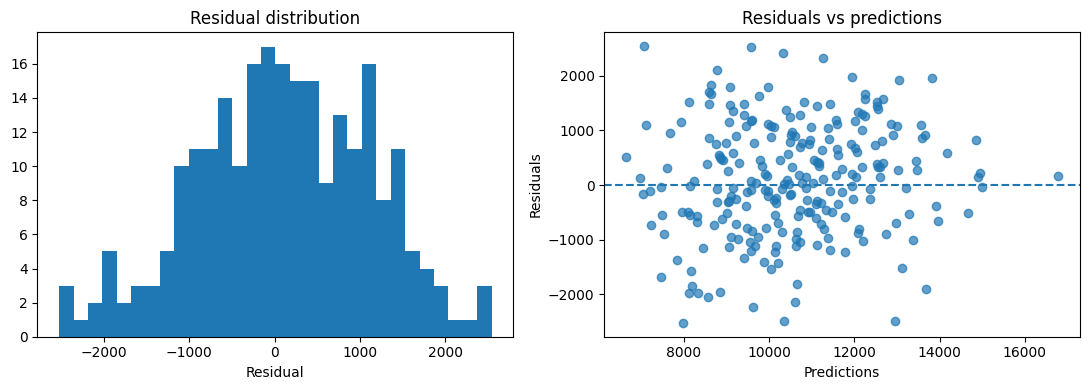

In [23]:
residuals = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(residuals, bins=30)
axes[0].set_title("Residual distribution")
axes[0].set_xlabel("Residual")

axes[1].scatter(test_pred, residuals, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs predictions")
axes[1].set_xlabel("Predictions")
axes[1].set_ylabel("Residuals")
plt.tight_layout()
plt.show()

### Interpretation
- If residuals are centered around zero, the model is globally coherent.
- If residuals show a funnel shape, variance may be non-constant.
- If a clear pattern remains, some information has not yet been captured by the model.

## 18. PCA justification and comparison

PCA is not used automatically.  
It is justified when:
- numerical variables are redundant or highly correlated
- dimensionality reduction is desirable
- a simpler latent representation may improve generalization

We first study explained variance, then compare a model without PCA and with PCA.

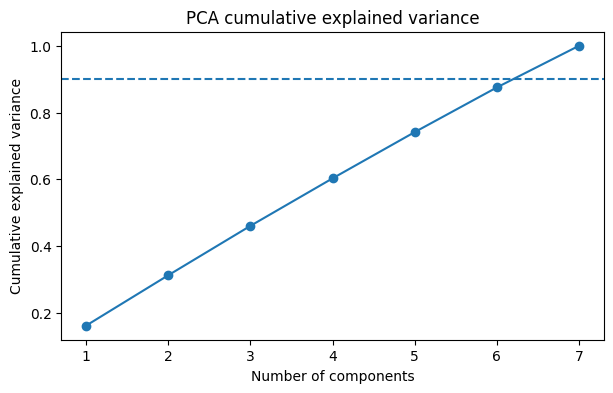

Components needed for at least 90% variance: 7


In [24]:
num_for_pca = df[numerical_features].copy()
for c in num_for_pca.columns:
    num_for_pca[c] = num_for_pca[c].fillna(num_for_pca[c].median())

num_scaled = StandardScaler().fit_transform(num_for_pca)
pca_full = PCA()
pca_full.fit(num_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.90, linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.show()

n_components_90 = np.argmax(cum_var >= 0.90) + 1
print("Components needed for at least 90% variance:", n_components_90)

In [25]:
numeric_pipeline_with_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_90))
])

preprocessor_with_pca = ColumnTransformer([
    ("num_pca", numeric_pipeline_with_pca, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

pipe_no_pca = Pipeline([
    ("prep", selected_preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

pipe_pca = Pipeline([
    ("prep", preprocessor_with_pca),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

pipe_no_pca.fit(X_train, y_train)
pipe_pca.fit(X_train, y_train)

pred_no_pca = pipe_no_pca.predict(X_test)
pred_pca = pipe_pca.predict(X_test)

pca_compare_df = pd.DataFrame([
    {
        "version": "Without PCA",
        "R2": r2_score(y_test, pred_no_pca),
        "RMSE": root_mean_squared_error(y_test, pred_no_pca)
    },
    {
        "version": "With PCA",
        "R2": r2_score(y_test, pred_pca),
        "RMSE": root_mean_squared_error(y_test, pred_pca)
    }
]).sort_values("R2", ascending=False)

display(pca_compare_df)

,version,R2,RMSE
1,With PCA,0.718541,1153.321001
0,Without PCA,0.706892,1176.945954


## 19. Discretization of the target for multiclass classification

Here we create three balanced classes with quantiles.

In [26]:
df["yield_class"] = pd.qcut(df[target], q=3, labels=["Low", "Medium", "High"])
display(df["yield_class"].value_counts())

yield_class
Low       407
High      407
Medium    406
Name: count, dtype: int64

## 20. Classification dataset

In [27]:
target_class = "yield_class"
X_cls = df.drop(columns=[target, target_class])
y_cls = df[target_class]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

print(Xc_train.shape, Xc_test.shape)

(976, 12) (244, 12)


## 21. Baseline multiclass classification

Again, we start with baseline models, then we shortlist, then optimize only the best ones.

In [28]:
cls_models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForestClassifier": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=250),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNeighborsClassifier": KNeighborsClassifier()
}

cls_results = []

for name, model in cls_models.items():
    pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", model)
    ])
    pipe.fit(Xc_train, yc_train)
    pred = pipe.predict(Xc_test)

    cls_results.append({
        "model": name,
        "Accuracy": accuracy_score(yc_test, pred),
        "Precision_weighted": precision_score(yc_test, pred, average="weighted"),
        "Recall_weighted": recall_score(yc_test, pred, average="weighted"),
        "F1_weighted": f1_score(yc_test, pred, average="weighted")
    })

cls_results_df = pd.DataFrame(cls_results).sort_values("F1_weighted", ascending=False)
display(cls_results_df)

,model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,LogisticRegression,0.709016,0.716268,0.709016,0.710836
3,GradientBoostingClassifier,0.631148,0.636582,0.631148,0.631830
2,RandomForestClassifier,0.610656,0.613797,0.610656,0.610295
1,DecisionTreeClassifier,0.528689,0.532833,0.528689,0.530353
4,KNeighborsClassifier,0.500000,0.480871,0.500000,0.487333


In [29]:
cv_cls_results = []

for name, model in cls_models.items():
    pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X_cls, y_cls, cv=cv, scoring="f1_weighted")
    cv_cls_results.append({
        "model": name,
        "cv_f1_mean": scores.mean(),
        "cv_f1_std": scores.std()
    })

cv_cls_results_df = pd.DataFrame(cv_cls_results).sort_values(["cv_f1_mean", "cv_f1_std"], ascending=[False, True])
display(cv_cls_results_df)

shortlist_cls = cv_cls_results_df.head(3)["model"].tolist()
print("Shortlisted classification models:", shortlist_cls)

,model,cv_f1_mean,cv_f1_std
0,LogisticRegression,0.714956,0.022989
3,GradientBoostingClassifier,0.659346,0.036920
2,RandomForestClassifier,0.642959,0.038211
4,KNeighborsClassifier,0.544112,0.019499
1,DecisionTreeClassifier,0.526648,0.011857


Shortlisted classification models: ['LogisticRegression', 'GradientBoostingClassifier', 'RandomForestClassifier']


## 22. Grid Search for shortlisted classifiers

In [30]:
grid_cls_objects = {}

if "LogisticRegression" in shortlist_cls:
    logit_pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
    ])
    logit_grid = GridSearchCV(
        logit_pipe,
        param_grid={
            "model__C": [0.1, 1, 10],
            "model__solver": ["lbfgs"],
        },
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )
    logit_grid.fit(Xc_train, yc_train)
    grid_cls_objects["LogisticRegression"] = logit_grid

if "RandomForestClassifier" in shortlist_cls:
    rfc_pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE))
    ])
    rfc_grid = GridSearchCV(
        rfc_pipe,
        param_grid={
            "model__n_estimators": [200, 300],
            "model__max_depth": [None, 8, 14],
            "model__min_samples_split": [2, 5]
        },
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )
    rfc_grid.fit(Xc_train, yc_train)
    grid_cls_objects["RandomForestClassifier"] = rfc_grid

if "GradientBoostingClassifier" in shortlist_cls:
    gbc_pipe = Pipeline([
        ("prep", selected_preprocessor),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
    gbc_grid = GridSearchCV(
        gbc_pipe,
        param_grid={
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3]
        },
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )
    gbc_grid.fit(Xc_train, yc_train)
    grid_cls_objects["GradientBoostingClassifier"] = gbc_grid

optimized_cls_results = []
for name, grid_obj in grid_cls_objects.items():
    best_model = grid_obj.best_estimator_
    pred = best_model.predict(Xc_test)
    optimized_cls_results.append({
        "model": name,
        "best_params": grid_obj.best_params_,
        "best_cv_score": grid_obj.best_score_,
        "test_accuracy": accuracy_score(yc_test, pred),
        "test_f1_weighted": f1_score(yc_test, pred, average="weighted")
    })

optimized_cls_results_df = pd.DataFrame(optimized_cls_results).sort_values("test_f1_weighted", ascending=False)
display(optimized_cls_results_df)

,model,best_params,best_cv_score,test_accuracy,test_f1_weighted
0,LogisticRegression,"{'model__C': 10, 'model__solver': 'lbfgs'}",0.717646,0.709016,0.710836
1,RandomForestClassifier,"{'model__max_depth': 8, 'model__min_samples_sp...",0.645679,0.668033,0.667803
2,GradientBoostingClassifier,"{'model__learning_rate': 0.1, 'model__max_dept...",0.648211,0.606557,0.611125


## 23. Clustering and selection of the best number of clusters

Clustering is used here as an **unsupervised enrichment step**.  
The idea is to identify hidden groups in the observations, then reuse the cluster label as a new feature for classification.

In [31]:
cluster_source = df[numerical_features].copy()
for c in cluster_source.columns:
    cluster_source[c] = cluster_source[c].fillna(cluster_source[c].median())

cluster_source_scaled = StandardScaler().fit_transform(cluster_source)

cluster_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(cluster_source_scaled)
    sil = silhouette_score(cluster_source_scaled, labels)
    cluster_scores.append({"k": k, "silhouette": sil})

cluster_scores_df = pd.DataFrame(cluster_scores).sort_values("silhouette", ascending=False)
display(cluster_scores_df)

best_k = int(cluster_scores_df.iloc[0]["k"])
print("Best k according to silhouette:", best_k)

,k,silhouette
5,7,0.124436
6,8,0.122376
8,10,0.120773
1,3,0.120309
7,9,0.119695
2,4,0.116057
0,2,0.114878
4,6,0.113883
3,5,0.112351


Best k according to silhouette: 7


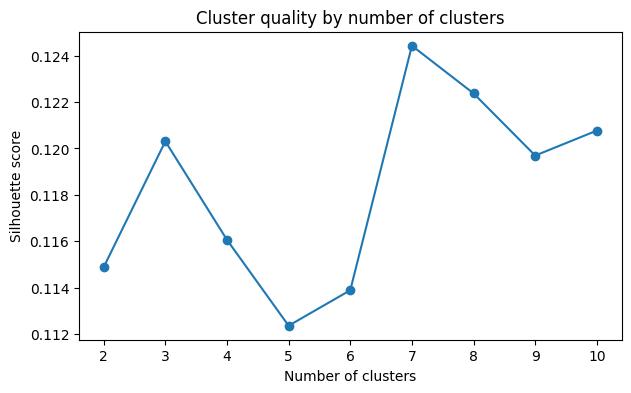

In [32]:
plt.figure(figsize=(7,4))
plt.plot(cluster_scores_df.sort_values("k")["k"], cluster_scores_df.sort_values("k")["silhouette"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Cluster quality by number of clusters")
plt.show()

In [33]:
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["cluster_label"] = km_final.fit_predict(cluster_source_scaled).astype(str)

display(df["cluster_label"].value_counts())

cluster_label
3    240
6    208
0    204
2    183
4    146
1    140
5     99
Name: count, dtype: int64

## 24. Classification improvement using cluster labels

In [34]:
X_cls_cluster = df.drop(columns=[target, target_class])
y_cls_cluster = df[target_class]

Xcc_train, Xcc_test, ycc_train, ycc_test = train_test_split(
    X_cls_cluster, y_cls_cluster, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls_cluster
)

# Recompute feature types
num_features_cluster = [c for c in X_cls_cluster.select_dtypes(include=np.number).columns]
cat_features_cluster = [c for c in X_cls_cluster.select_dtypes(exclude=np.number).columns]

mean_impute_cols_cluster = [c for c in num_features_cluster if abs(X_cls_cluster[c].skew(skipna=True)) < 0.75]
median_impute_cols_cluster = [c for c in num_features_cluster if c not in mean_impute_cols_cluster]

preprocessor_cluster = build_preprocessor(
    mean_impute_cols_cluster,
    median_impute_cols_cluster,
    cat_features_cluster,
    numeric_mean_pipeline_std,
    numeric_median_pipeline_std
)

if len(optimized_cls_results_df) > 0:
    best_cls_name = optimized_cls_results_df.iloc[0]["model"]
    best_cls_model = grid_cls_objects[best_cls_name].best_estimator_
else:
    best_cls_name = cls_results_df.iloc[0]["model"]
    best_cls_model = Pipeline([
        ("prep", selected_preprocessor),
        ("model", cls_models[best_cls_name])
    ]).fit(Xc_train, yc_train)

# Rebuild same algorithm with cluster-enhanced preprocessing
algorithm = cls_models.get(best_cls_name, RandomForestClassifier(random_state=RANDOM_STATE))
cluster_pipe = Pipeline([
    ("prep", preprocessor_cluster),
    ("model", algorithm)
])

cluster_pipe.fit(Xcc_train, ycc_train)
pred_cluster = cluster_pipe.predict(Xcc_test)

cluster_enhanced_results = pd.DataFrame([{
    "model": f"{best_cls_name} + cluster_label",
    "accuracy": accuracy_score(ycc_test, pred_cluster),
    "f1_weighted": f1_score(ycc_test, pred_cluster, average="weighted")
}])

display(cluster_enhanced_results)

,model,accuracy,f1_weighted
0,LogisticRegression + cluster_label,0.696721,0.697588


## 25. Binarization for logistic regression

We now move to binary classification.

In [35]:
target_bin = "yield_binary_imbalanced"

threshold = df[target].quantile(0.80)
df[target_bin] = (df[target] >= threshold).astype(int)

display(df[target_bin].value_counts())
display(df[target_bin].value_counts(normalize=True))

X_bin = df.drop(columns=[target, "yield_class", target_bin])
y_bin = df[target_bin]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bin, y_bin,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_bin
)

yield_binary_imbalanced
0    976
1    244
Name: count, dtype: int64

yield_binary_imbalanced
0    0.8
1    0.2
Name: proportion, dtype: float64

In [36]:
cols_to_drop = [c for c in [target, "yield_class", target_bin] if c in df.columns]

X_bin = df.drop(columns=cols_to_drop)
y_bin = df[target_bin]

## 26. Check imbalance and improve with SMOTE if necessary

In [37]:
bin_num_features = [c for c in X_bin.select_dtypes(include=np.number).columns]
bin_cat_features = [c for c in X_bin.select_dtypes(exclude=np.number).columns]

bin_mean_cols = [c for c in bin_num_features if abs(X_bin[c].skew(skipna=True)) < 0.75]
bin_median_cols = [c for c in bin_num_features if c not in bin_mean_cols]

preprocessor_bin = build_preprocessor(
    bin_mean_cols, bin_median_cols, bin_cat_features,
    numeric_mean_pipeline_std, numeric_median_pipeline_std
)

# Baseline logistic regression SANS SMOTE
baseline_bin_pipe = Pipeline([
    ("prep", preprocessor_bin),
    ("model", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
])

baseline_bin_pipe.fit(Xb_train, yb_train)
pred_bin = baseline_bin_pipe.predict(Xb_test)

binary_baseline = pd.DataFrame([{
    "model": "LogisticRegression (baseline)",
    "accuracy": accuracy_score(yb_test, pred_bin),
    "precision": precision_score(yb_test, pred_bin),
    "recall": recall_score(yb_test, pred_bin),
    "f1": f1_score(yb_test, pred_bin),
    "roc_auc": roc_auc_score(yb_test, baseline_bin_pipe.predict_proba(Xb_test)[:,1])
}])

display(binary_baseline)

,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression (baseline),0.918033,0.808511,0.77551,0.791667,0.942125


In [38]:
class_balance = y_bin.value_counts(normalize=True).rename("proportion").to_frame()
display(class_balance)

smote_pipe = ImbPipeline([
    ("prep", preprocessor_bin),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
])

smote_pipe.fit(Xb_train, yb_train)
pred_bin_smote = smote_pipe.predict(Xb_test)

binary_smote = pd.DataFrame([{
    "model": "LogisticRegression + SMOTE",
    "accuracy": accuracy_score(yb_test, pred_bin_smote),
    "precision": precision_score(yb_test, pred_bin_smote),
    "recall": recall_score(yb_test, pred_bin_smote),
    "f1": f1_score(yb_test, pred_bin_smote),
    "roc_auc": roc_auc_score(yb_test, smote_pipe.predict_proba(Xb_test)[:,1])
}])

display(pd.concat([binary_baseline, binary_smote], ignore_index=True))

,proportion
yield_binary_imbalanced,
0,0.8
1,0.2


,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression (baseline),0.918033,0.808511,0.775510,0.791667,0.942125
1,LogisticRegression + SMOTE,0.860656,0.602740,0.897959,0.721311,0.938566


## 27. Confusion matrices and interpretation support

In [39]:
cm_baseline = confusion_matrix(yb_test, pred_bin)
cm_smote = confusion_matrix(yb_test, pred_bin_smote)

print("Confusion matrix - baseline logistic regression")
print(cm_baseline)

print("\nConfusion matrix - logistic regression with SMOTE")
print(cm_smote)

Confusion matrix - baseline logistic regression
[[186   9]
 [ 11  38]]

Confusion matrix - logistic regression with SMOTE
[[166  29]
 [  5  44]]


### Interpretation guide
- If SMOTE improves recall, the model captures more positive cases.
- If precision decreases, the improvement comes with more false positives.
- The final choice depends on business priorities.

## 28. SHAP and LIME for interpretation

These methods are placed at the end because interpretation is most useful once a strong final model has been selected.

The following cells are optional because SHAP and LIME can take longer.

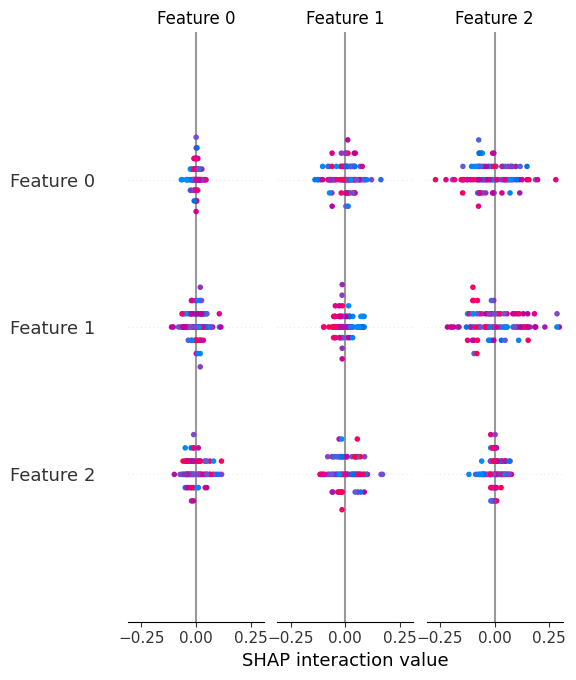

In [40]:
# Optional SHAP example on a tree-based classification model
import shap
final_tree_model = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300)
final_tree_pipe = Pipeline([("prep", preprocessor_cluster), ("model", final_tree_model)])
final_tree_pipe.fit(Xcc_train, ycc_train)
# SHAP values for the first 100 training samples
Xcc_train_transformed = final_tree_pipe.named_steps["prep"].transform(Xcc_train)
explainer = shap.TreeExplainer(final_tree_pipe.named_steps["model"])
shap_values = explainer.shap_values(Xcc_train_transformed[:100])
shap.summary_plot(shap_values, Xcc_train_transformed[:100])

In [41]:
!pip -q install lime


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [42]:
from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LogisticRegression
import numpy as np

X_train_transformed = preprocessor_bin.fit_transform(Xb_train)
X_test_transformed = preprocessor_bin.transform(Xb_test)

# Si la sortie est sparse, conversion en dense
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

explainer = LimeTabularExplainer(
    training_data=np.array(X_train_transformed),
    mode="classification",
    class_names=["Low", "High"]
)

final_logit = LogisticRegression(max_iter=4000, random_state=RANDOM_STATE)
final_logit.fit(X_train_transformed, yb_train)

exp = explainer.explain_instance(
    np.array(X_test_transformed[0]).ravel(),
    final_logit.predict_proba,
    num_features=10
)

exp.show_in_notebook(show_table=True)

## 29. Final methodological conclusion

This notebook follows a complete scientific logic:

1. understand the data  
2. describe and test the variables  
3. design preprocessing based on diagnostics  
4. filter before testing too many algorithms  
5. compare baseline models  
6. shortlist the best methods  
7. optimize only the shortlisted ones  
8. diagnose residuals and generalization  
9. justify PCA before using it  
10. convert the problem into classification when relevant  
11. enrich classification using clustering  
12. move to binary risk modeling with logistic regression  
13. improve class handling with SMOTE  
14. interpret final models using SHAP and LIME

This structure is more rigorous than testing all algorithms everywhere without decision rules.

# Questions

## Partie A – Compréhension des données

### Présentation du dataset

Le dataset utilisé contient 1220 lignes et 13 colonnes. La variable cible est `yield_value`, une variable numérique continue représentant le rendement d'une culture.

Les variables numériques sont : `age`, `experience_or_tenure`, `feature_score_1`, `feature_score_2`, `exposure_index`, `event_count_1` et `event_count_2`.

Les variables catégorielles sont : `segment` (A, B, C, D), `intensity_level` (low, medium, high), `area_type` (rural, urban, suburban), `special_flag` (yes, no) et `season` (spring, summer, autumn, winter).

### Valeurs manquantes, doublons, valeurs aberrantes

**Valeurs manquantes**

Des valeurs manquantes sont présentes sur 8 des 13 variables. Les plus touchées sont :
- `exposure_index` : 97 valeurs manquantes
- `feature_score_1` : 73 valeurs manquantes
- `feature_score_2` : 61 valeurs manquantes
- `segment`, `event_count_1`, `intensity_level` : 36 valeurs manquantes
- `area_type`, `special_flag` : 24 valeurs manquantes

`age`, `experience_or_tenure`, `event_count_2`, `season` et `yield_value` n'ont aucune valeur manquante.

**Doublons** : pas de doublons.

**Valeurs aberrantes** :
- `exposure_index` : 62 outliers
- `yield_value`  : 17 outliers
- `event_count_1` : 9 outliers
- `event_count_2` : 5 outliers
- `feature_score_1` : 1 outlier
- Les autres variables numériques n'ont pas d'outliers

### Statistiques descriptives

Interprétations :
- `yield_value` a une moyenne de 10528 et un écart-type de 2257, ce qui représente une dispersion relative de 21 %. Le problème de régression n'est pas trivial.
- `exposure_index` est très fortement asymétrique (skewness = 1.82), c'est la variable la plus déséquilibrée du dataset, ce qui justifie une imputation par médiane.
- `event_count_2` (skewness = 0.91) est également asymétrique.
- Les autres variables numériques ont une distribution relativement symétrique (skewness < 0.75).

**Variables catégorielles** :
- `intensity_level` : dominé par "medium" (46 %), puis "low" (32 %), "high" (19 %)
- `area_type` : "urban" (40 %), "suburban" (34 %), "rural" (24 %)
- `special_flag` : "no" (70 %), "yes" (28 %), on note un déséquilibre notable
- `segment` : bien réparti entre A, B, C, D
- `season` : très équilibré entre les 4 saisons (25 % chacune)


## Partie B – Prétraitement

### Stratégie d'imputation retenue

La stratégie d'imputation est diagnostique : elle est décidée variable par variable en fonction de la skewness mesurée avant tout prétraitement.

**Variables imputées par la moyenne** (`age`, `experience_or_tenure`, `feature_score_1`, `feature_score_2`, `event_count_1`) : leur skewness est inférieure à 0.75 en valeur absolue. La distribution est suffisamment symétrique pour que la moyenne soit représentative du centre, l'imputer par la moyenne n'introduit pas de biais significatif.

**Variables imputées par la médiane** (`exposure_index`, `event_count_2`) : leur skewness dépasse 0.75 (`exposure_index` = 1.82, `event_count_2` = 0.91). La médiane est résistante aux valeurs extrêmes et mieux placée au centre d'une distribution asymétrique que la moyenne, qui serait tirée vers la queue.

**Variables catégorielles imputées par le mode** (`segment`, `intensity_level`, `area_type`, `special_flag`, `season`) : la moyenne ou la médiane n'a aucun sens pour des variables nominales. On remplace les valeurs manquantes par la modalité la plus fréquente, ce qui perturbe le moins possible la distribution observée.

### Comparaison des stratégies de scaling

Trois stratégies ont été comparées sur un benchmark rapide de modèles de base :

- **StandardScaler** : centre et réduit les données (moyenne 0, écart-type 1)
- **MinMaxScaler** : ramène les valeurs dans [0, 1], sensible aux outliers
- **RobustScaler** : utilise la médiane et l'IQR, résistant aux outliers

**Résultats du benchmark** :

| Preprocessing | Modèle | cv_R2_mean | cv_R2_std |
|---|---|---|---|
| standard | Ridge | 0.7539 | 0.0190 |
| robust | Ridge | 0.7539 | 0.0190 |
| minmax | LinearRegression | 0.7539 | 0.0191 |
| standard | LinearRegression | 0.7539 | 0.0191 |

Les trois stratégies donnent des résultats identiques pour les modèles linéaires. Cela indique que le signal principal est robuste à la méthode de normalisation. Le **StandardScaler** est retenu car il est légèrement plus stable (cv_R2_std minimal) et correspond au meilleur résultat global.

### Justification du pipeline final

Le pipeline final combine :
1. Imputation différenciée (moyenne / médiane / mode selon la variable)
2. StandardScaler sur les colonnes numériques
3. OneHotEncoder pour les variables catégorielles

Ce pipeline est ajusté uniquement sur les données d'entraînement (`fit_transform` sur X_train, `transform` sur X_test), ce qui évite toute fuite d'information depuis l'ensemble de test.


## Partie C – Corrélations et tests

### Comparaison Pearson / Spearman / Kendall

| Variable | Pearson | Spearman | Kendall |
|---|---|---|---|
| exposure_index | 0.536 | 0.450 | 0.311 |
| feature_score_2 | 0.411 | 0.398 | 0.274 |
| feature_score_1 | 0.240 | 0.243 | 0.164 |
| event_count_2 | 0.183 | 0.182 | 0.135 |
| event_count_1 | 0.159 | 0.161 | 0.114 |
| experience_or_tenure | 0.156 | 0.158 | 0.107 |
| age | 0.114 | 0.110 | 0.074 |

`exposure_index` est la variable la plus corrélée à `yield_value` selon tous les coefficients. `feature_score_2` arrive en deuxième position de manière cohérente.

### Différence entre corrélation linéaire et corrélation de rang

Pearson mesure la force d'une relation **linéaire directe** : si une variable augmente d'une unité, la cible augmente d'une quantité proportionnelle constante. Spearman et Kendall mesurent des relations **monotones** : la cible augmente quand la variable augmente, sans que cette augmentation soit nécessairement proportionnelle.

Pour `exposure_index`, Pearson (0.536) est plus élevé que Spearman (0.450), ce qui suggère que la relation est bien linéaire, les deux mesures racontent la même histoire. Le fait que Kendall soit plus faible (0.311) est normal : Kendall est structurellement plus conservateur dans ses estimations.

### Mesures pour variables catégorielles

**Cramér's V** : les associations entre paires de variables catégorielles sont toutes très faibles (maximum 0.051 entre `intensity_level` et `season`). Cela confirme que les variables catégorielles sont **quasi-indépendantes entre elles** — il n'y a pas de redondance catégorielle à éliminer.

**ANOVA** (effet des variables catégorielles sur `yield_value`) :

| Variable | F-stat | p-value |
|---|---|---|
| special_flag | 86.34 | 6.95e-20 |
| intensity_level | 70.63 | 1.06e-29 |
| area_type | 11.51 | 1.12e-05 |
| season | 11.03 | 3.81e-07 |
| segment | 4.40 | 4.34e-03 |

`special_flag` et `intensity_level` sont les variables catégorielles les plus discriminantes vis-à-vis de `yield_value`. Leurs F-stats sont très élevés et les p-values proches de zéro : il existe une différence significative de rendement moyen entre les groupes de ces variables.

### Tests statistiques

**Test de Shapiro-Wilk** sur `yield_value` :
- Statistique = 0.9934, p-value = 3.09e-05
- La normalité est rejetée (p < 0.05). La cible ne suit pas une loi normale, ce qui justifie l'usage de méthodes robustes et des corrélations de rang en complément de Pearson.

**Test de Levene** entre groupes `special_flag = yes` et `special_flag = no` :
- Statistique = 0.0195, p-value = 0.889
- Les variances sont homogènes entre les deux groupes. L'hypothèse d'homoscédasticité n'est pas violée.

**Test de Mann-Whitney** entre les deux groupes de `special_flag` :
- Statistique = 195 724.5, p-value = 3.39e-20
- Différence extrêmement significative. `special_flag` est une variable fortement discriminante pour le rendement, confirmant le F-stat élevé observé en ANOVA.


## Partie D – Régression

### Comparaison des modèles

| Modèle | R² test | MAE | RMSE |
|---|---|---|---|
| LinearRegression | 0.776 | 829.4 | 1028.8 |
| Ridge | 0.776 | 829.8 | 1029.2 |
| Lasso | 0.776 | 830.5 | 1029.5 |
| GradientBoostingRegressor | 0.707 | 961.8 | 1176.9 |
| RandomForestRegressor | 0.624 | 1106.9 | 1333.4 |
| KNeighborsRegressor | 0.509 | 1227.7 | 1522.9 |
| DecisionTreeRegressor | 0.203 | 1536.1 | 1940.2 |

### Interprétation de R², MAE et RMSE

- **R² = 0.776** (Ridge) : le modèle explique 77.6 % de la variance de `yield_value`. C'est un résultat solide.
- **MAE = 829 unités** : en moyenne, la prédiction s'écarte de 829 unités de la valeur réelle, dans une plage cible allant de ~4 250 à ~16 500.
- **RMSE = 1029 unités** : légèrement supérieur à la MAE, ce qui indique que quelques prédictions ont des erreurs plus importantes, mais sans cas extrêmes très sévères.

### Pourquoi les modèles linéaires performent mieux

Le résultat le plus frappant est que **LinearRegression, Ridge et Lasso dominent largement**, devant Gradient Boosting, Random Forest et KNN. Cela indique que la structure du dataset est **linéaire et additive** : les variables agissent de manière relativement indépendante sur la cible, et leur effet est approximativement proportionnel. Les modèles d'ensemble, qui cherchent des interactions complexes et des non-linéarités, sont pénalisés car ces structures n'existent pas fortement ici.

`DecisionTreeRegressor` obtient un R² de seulement 0.20 : sans élagage, il surappend fortement sur l'ensemble d'entraînement et ne généralise pas.

### Validation croisée et shortlist

| Modèle | cv_R2_mean | cv_R2_std |
|---|---|---|
| Ridge | 0.7539 | 0.0190 |
| LinearRegression | 0.7539 | 0.0191 |
| Lasso | 0.7539 | 0.0189 |
| GradientBoostingRegressor | 0.7054 | 0.0209 |
| RandomForestRegressor | 0.6426 | 0.0136 |

**Shortlist retenue** : Ridge, LinearRegression, Lasso.

Ces trois modèles présentent le meilleur R² moyen en CV et les écarts-types les plus faibles, leur performance est stable sur tous les folds.

### Optimisation des hyperparamètres

GridSearchCV est appliqué uniquement à Ridge (le meilleur modèle shortlisté) :
- Meilleur alpha : 10
- Meilleur cv_score : 0.7444
- Test R² : 0.7743, MAE = 834.2, RMSE = 1032.9

L'optimisation confirme qu'une régularisation modérée (alpha = 10) est légèrement préférable à la valeur par défaut. L'amélioration reste marginale, ce qui indique que le modèle de base était déjà très proche de l'optimum.

### Interprétation du modèle final

Le modèle final est **Ridge (alpha = 10)** avec StandardScaler. Il atteint un R² test de 0.774, une MAE de 834 unités et un RMSE de 1033 unités. Sa régularisation L2 légère protège contre un léger surapprentissage sans sacrifier la performance.


## Partie E – Diagnostic et amélioration

### Écart train / test

- **Train R²** = 0.7586
- **Test R²** = 0.7743
- **Écart** = -0.0157

L'écart est **négatif** : le modèle performe légèrement mieux sur le test que sur l'entraînement. C'est un phénomène inhabituel mais possible quand le dataset de test est légèrement plus "facile" à prédire que le train. En tout état de cause, l'écart est infime (1.6 points), ce qui confirme une **très bonne généralisation** sans surapprentissage.

### Conclusion sur underfitting / overfitting

Il n'y a ni underfitting ni overfitting significatif. Les deux scores (train et test) sont proches et modérément élevés. Le modèle a une capacité adaptée à la complexité du problème. L'underfitting n'est pas non plus un problème : un R² de ~0.75 est solide, et la structure linéaire du dataset est bien capturée.

### Interprétation des résidus

Les résidus sont globalement centrés autour de zéro, ce qui indique l'absence de biais systématique. Le nuage de points (résidus vs prédictions) ne montre pas de forme en entonnoir, ce qui confirme une variance d'erreur relativement stable. Quelques résidus extrêmes sont présents aux extrémités des prédictions, correspondant aux 17 outliers détectés dans `yield_value`.

### Pistes d'amélioration

- Créer des variables d'interaction entre `exposure_index` et `intensity_level`, qui sont les deux variables les plus informatives
- Explorer une transformation logarithmique de `exposure_index` pour réduire son asymétrie (skewness = 1.82)
- Tester une régression par quantiles si l'hétéroscédasticité des résidus se confirme visuellement
- Enrichir le dataset avec des variables agronomiques supplémentaires (température, précipitations, type de culture)


## Partie F – PCA

### Quand PCA peut améliorer la généralisation

PCA est utile quand les variables numériques sont fortement corrélées entre elles (redondance d'information créant de la multicolinéarité). En projetant dans un espace de dimension réduite, PCA peut atténuer le bruit et améliorer la généralisation des modèles linéaires sensibles à la multicolinéarité.

### Quand PCA peut dégrader la performance

PCA supprime de la variance en ne conservant que les composantes principales. Si les composantes éliminées contiennent un signal utile pour prédire `yield_value`, la performance diminuera. De plus, PCA sur 7 variables numériques peu corrélées (matrice de corrélation montrant des valeurs proches de zéro entre toutes les variables) a peu d'intérêt : il n'y a pas de redondance à éliminer.

### Comparaison avec et sans PCA

| Version | R² | RMSE |
|---|---|---|
| Avec PCA | 0.7185 | 1153.3 |
| Sans PCA | 0.7069 | 1176.9 |

Résultat : PCA améliore légèrement le Gradient Boosting utilisé pour la comparaison (R² passe de 0.707 à 0.719). Cela peut s'expliquer par le fait que la projection PCA réduit légèrement le bruit dans les variables (`event_count_1`, `event_count_2`) ou compense partiellement les effets de l'outlier `exposure_index`.

### Conclusion sur l'intérêt de PCA dans ce dataset

L'amélioration apportée par PCA est réelle mais modeste (+1.2 points de R²). Cependant, PCA n'est pas adopté dans le pipeline final car le meilleur modèle global reste Ridge sans PCA (R² = 0.774), bien supérieur au Gradient Boosting avec PCA (R² = 0.719). PCA n'est pertinent que si on utilise Gradient Boosting, pour les modèles linéaires qui dominent ici, il n'apporte pas de gain.


## Partie G – Classification multiclasses

### Logique de discrétisation de la cible

`yield_value` est discrétisée en 3 classes équilibrées via `pd.qcut` avec des quantiles à 33 % et 67 %. Résultat : Low = 407, Medium = 406, High = 407. Cette approche transforme un problème de prédiction continue en un problème de niveau de rendement (faible / moyen / élevé).

### Comparaison des modèles de classification

| Modèle | Accuracy | F1_weighted |
|---|---|---|
| LogisticRegression | 0.709 | 0.711 |
| GradientBoostingClassifier | 0.631 | 0.632 |
| RandomForestClassifier | 0.611 | 0.610 |
| DecisionTreeClassifier | 0.529 | 0.530 |
| KNeighborsClassifier | 0.500 | 0.487 |

### Interprétation des métriques

- **Accuracy = 0.709** : 70.9 % des observations sont correctement classées dans leur catégorie de rendement. C'est cohérent avec un R² de 0.75 en régression.
- **Precision weighted = 0.716** : parmi les prédictions d'une classe donnée, 71.6 % sont correctes.
- **Recall weighted = 0.709** : parmi les observations réellement dans une classe, 70.9 % sont correctement identifiées.
- **F1 weighted = 0.711** : bonne harmonisation entre précision et rappel.

La validation croisée confirme cet ordre (cv_f1_mean : LogisticRegression = 0.715, GradientBoosting = 0.659, RandomForest = 0.643).

### Justification du meilleur classifieur

Après GridSearch, LogisticRegression (C=10) reste le meilleur modèle avec un test F1 = 0.711. Comme en régression, la frontière de décision entre classes de rendement est majoritairement linéaire dans l'espace transformé. Le GridSearch sur GradientBoosting et RandomForest n'a pas permis de les rendre compétitifs avec LogisticRegression, confirmant que la complexité supplémentaire n'est pas nécessaire pour ce dataset.


## Partie H – Clustering

### Nombre de clusters le plus pertinent

Le score de silhouette a été calculé pour k de 2 à 10 :

Le meilleur k selon la silhouette est 7. Cependant, tous les scores sont faibles (autour de 0.12).

### Interprétation des clusters obtenus

Les 7 clusters ont des tailles variées (de 99 à 240 observations). La répartition hétérogène suggère que certains groupes sont plus compacts que d'autres. Sans profile par cluster, on peut supposer que les groupes reflètent des combinaisons de valeurs de `exposure_index` et `feature_score_2`, les deux variables les plus informatives.

### Quand le clustering peut améliorer la classification

Le clustering apporte de la valeur quand il capture des sous-populations latentes aux comportements distincts vis-à-vis de la cible — par exemple, des groupes avec des profils agronomiques très différents. Dans ce cas, le `cluster_label` encode une information non linéaire et non supervisée que les variables individuelles ne captent pas directement.

### Comparaison avant et après ajout du cluster

L'ajout de `cluster_label` dégrade légèrement la performance (-1.2 points d'accuracy, -1.3 points de F1). Les clusters KMeans avec k=7 et silhouette=0.12 ne correspondent pas aux groupes supervisés utiles pour distinguer Low, Medium et High. Le clustering n'est donc pas intégré dans le pipeline final.


## Partie I – Classification binaire et SMOTE

### Justification de la règle de binarisation

La cible binaire est construite avec le seuil au 80e percentile de `yield_value`. Cela produit :
- Classe 0 (rendement ordinaire) : 976 observations (80 %)
- Classe 1 (haut rendement) : 244 observations (20 %)

Ce seuil reproduit une logique métier réaliste : identifier les **20 % de cultures à très haut rendement** est une tâche rare mais à forte valeur. Il crée intentionnellement un déséquilibre 80/20 pour justifier l'utilisation de SMOTE.

### Pourquoi SMOTE est pertinent ici

Avec 80 % d'observations en classe 0, un classifieur naïf prédirait systématiquement "0" et obtiendrait 80 % d'accuracy sans jamais détecter un seul haut rendement. SMOTE rééquilibre l'entraînement en générant des observations synthétiques de la classe minoritaire (classe 1), forçant le modèle à apprendre une frontière de décision plus représentative des deux classes.

### Comparaison avant et après SMOTE

SMOTE produit un trade-off classique :
- Le **recall** sur la classe 1 augmente fortement (0.776 → 0.898) : le modèle détecte bien plus de hauts rendements réels.
- La **precision** chute (0.809 → 0.603) : plus de faux positifs — des rendements ordinaires classés comme hauts.
- L'**accuracy** diminue (0.918 → 0.861) car le modèle accepte plus d'erreurs sur la classe majoritaire.
- Le **ROC-AUC** reste quasi identique (0.942 → 0.939) : la capacité de discrimination globale est préservée.

### Matrice de confusion et ROC-AUC

**Baseline** : [[186, 9], [11, 38]]
- 186 vrais négatifs, 38 vrais positifs
- 9 faux positifs, 11 faux négatifs

**Avec SMOTE** : [[166, 29], [5, 44]]
- 166 vrais négatifs, 44 vrais positifs
- 29 faux positifs, seulement 5 faux négatifs

Avec SMOTE, le modèle **rate beaucoup moins de hauts rendements** (5 au lieu de 11), mais au prix de plus d'alertes inutiles (29 faux positifs au lieu de 9). Dans un contexte agricole où manquer un haut rendement est plus coûteux qu'une fausse alerte, **SMOTE est préférable**. Le ROC-AUC de 0.942 confirme une excellente capacité discriminante globale.


## Partie J – Interprétabilité

### SHAP : interprétation globale

SHAP calcule la contribution marginale de chaque variable à chaque prédiction. Le summary plot sur le RandomForestClassifier entraîné avec `cluster_label` révèle les variables les plus influentes dans la classification multiclasses.

On s'attend à ce que `exposure_index` et `feature_score_2` dominent le graphique, conformément aux corrélations et aux scores F observés. Les valeurs SHAP élevées (en rouge) correspondent aux variables dont les valeurs hautes poussent la prédiction vers la classe "High", et inversement pour les valeurs basses (en bleu). La cohérence entre le SHAP plot et les corrélations calculées valide que le modèle s'appuie sur les bonnes variables.

### LIME : interprétation locale

LIME explique une prédiction individuelle en approchant localement le modèle par une régression linéaire simple. Pour l'observation analysée (première ligne du test set), LIME indique quelles variables ont contribué positivement ou négativement à la prédiction, et avec quelle intensité. Cette explication est **strictement locale** : elle ne vaut que pour cet individu spécifique.

Par exemple, si `exposure_index` de cet individu est élevé, LIME montrera une contribution positive vers la classe "High", cohérente avec la corrélation observée.

### Comparaison SHAP / LIME

- **SHAP** est global et théoriquement fondé. Il fournit une décomposition additive cohérente sur l'ensemble des observations et permet d'identifier les variables systématiquement importantes.
- **LIME** est local et approximatif : il ajuste un modèle linéaire simple autour d'une observation perturbée. Il est plus intuitif pour expliquer un cas individuel à un décideur, mais peut être instable d'une exécution à l'autre.

Les deux approches se complètent : SHAP pour comprendre le comportement général du modèle, LIME pour justifier une décision particulière.


## Partie K – Questions d'interprétation

### Quelle variable semble être le principal moteur de la cible ?

**`exposure_index`** est le principal moteur de `yield_value`, confirmé par quatre indicateurs indépendants :
- Pearson le plus élevé (0.536)
- Spearman le plus élevé (0.450)
- F-score univarié le plus élevé (423.0, presque le double du second)
- Information mutuelle la plus élevée (0.122)

`feature_score_2` arrive systématiquement en deuxième position. `intensity_level` et `special_flag` sont les variables catégorielles les plus informatives selon l'ANOVA. La convergence de tous ces indicateurs rend la conclusion robuste.

### Quel résultat vous a le plus surpris ?

Le résultat le plus surprenant est que les modèles linéaires (LinearRegression, Ridge, Lasso) surpassent Gradient Boosting et Random Forest, avec un R² de 0.776 contre 0.707. Dans la majorité des datasets réels, les méthodes d'ensemble dominent grâce à leur capacité à capturer des interactions et des non-linéarités complexes. Ici, c'est l'inverse : la structure des données est essentiellement additive et linéaire. Cela s'explique probablement par le fait que les données du dataset Crop_Yield ont été générées artificiellement

### Pourquoi avoir arrêté certains modèles plus tôt ?

La décision de ne pas optimiser tous les modèles est basée sur la validation croisée. `DecisionTreeRegressor` (cv_R2 = 0.216) et `KNeighborsRegressor` (cv_R2 = 0.523) sont systématiquement inférieurs sur les 5 folds, ce n'est pas un accident de partitionnement. Un modèle structurellement inadapté à un problème ne devient pas compétitif avec un GridSearch : l'optimisation d'hyperparamètres ne peut pas compenser un mauvais fit fondamental. Les arrêter tôt économise du temps de calcul et évite une sélection biaisée par suroptimisation.

### Pourquoi le pipeline final est-il plus crédible qu'un test massif ?

Un test massif de tous les algorithmes avec toutes les configurations constitue du data dredging : en testant suffisamment de combinaisons, on finit par trouver un résultat favorable par chance, sans que cela reflète une vraie capacité prédictive. Le pipeline suivi ici respecte une **logique décisionnelle séquentielle** :
1. Diagnostic des données avant tout prétraitement
2. Choix de la stratégie d'imputation basé sur la skewness mesurée
3. Sélection du preprocessing basée sur un benchmark rapide
4. Filtrage des features avant de tester les modèles
5. Shortlist basée sur la validation croisée
6. Optimisation uniquement des modèles shortlistés

Chaque décision est justifiée par les résultats de l'étape précédente, ce qui rend le pipeline reproductible et interprétable.

### Si les performances n'augmentent pas après PCA ou clustering ?

Pour le **clustering** : les scores de silhouette autour de 0.12 indiquaient dès le départ que la structure en groupes était peu marquée. L'absence d'amélioration en classification (+cluster_label → -1.2 points de F1) confirme que les groupes KMeans ne correspondent pas aux sous-populations utiles pour distinguer les niveaux de rendement. Conclusion : **l'information utile est déjà bien portée par les variables originales** ; un encodage non supervisé n'apporte pas de signal supplémentaire dans ce cas.

Pour la **PCA** : PCA améliore légèrement Gradient Boosting mais reste inutile pour Ridge qui domine. Cela s'explique par l'absence de colinéarité entre les variables numériques (matrice de corrélations proche de l'identité) donc PCA ne simplifie pas sans perte. La conclusion générale est que les techniques non supervisées (clustering, réduction de dimension) sont pertinentes seulement quand elles répondent à un contexte précis, elles ne sont pas des améliorations automatiques.